In [2]:
# implementing simple chat bot using langgraph


In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph , START , END


e:\RAG AGENTIC AI\AGENTIC_AI_WITH_LANGGRAPH\venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [15]:
# Reducers
from typing  import Annotated
from langgraph.graph.message import add_messages # reducer

In [16]:
class State(TypedDict):
    messages : Annotated[list,add_messages]

In [17]:
import os
from dotenv import load_dotenv
load_dotenv()

python-dotenv could not parse statement starting at line 8


True

In [18]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [19]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")

In [20]:
# llm.invoke("hello")

In [27]:
from langchain_groq import ChatGroq

# Initialize Groq LLM
llm_groq = ChatGroq(model="qwen/qwen3-32b")




# Option 2: Use invoke() with a dict (LangChain standard)
response = llm_groq.invoke( "Hello I am Harshit, and I like to do coding")
print(response)


content="<think>\nOkay, the user introduced himself as Harshit and said he likes coding. I need to respond in a friendly and encouraging way. Let me start by acknowledging his introduction. Maybe ask him what kind of coding projects he's working on to engage him further. I should keep the tone positive and show enthusiasm for his interest. Also, offer help if he has any questions. Let me make sure the response is concise and not too long. Avoid any technical jargon he might not be familiar with. Alright, that should cover it.\n</think>\n\nHello Harshit! 😊 Welcome to the wonderful world of coding! I'd love to hear what kind of projects you're working on or what programming languages you're exploring. Whether you're building apps, games, websites, or diving into data science - I'm here to help with any questions you might have. What excites you most about coding? 🚀" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 185, 'prompt_tokens': 20, 'total_tokens': 205,

In [28]:
# we will start with creating nodes

In [29]:
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}


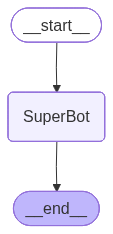

In [30]:
graph = StateGraph(State)

# node
graph.add_node("SuperBot",superbot)

# add edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder = graph.compile()

# Display 
from IPython.display import Image , display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [31]:
# Invocation

graph_builder.invoke({"messages":"Hi, my name is Harshit , and i love coding"})

{'messages': [HumanMessage(content='Hi, my name is Harshit , and i love coding', additional_kwargs={}, response_metadata={}, id='2a3b09dc-8003-4ac5-9762-9b28dafa512b'),
  AIMessage(content="<think>\nOkay, Harshit mentioned his name and that he loves coding. I should respond in a friendly and welcoming manner. Let me start by greeting him back and acknowledging his interest in coding.\n\nMaybe ask him what kind of projects he's working on or what languages he's interested in. That way, we can have a more engaging conversation. Also, offer help if he has any questions or needs advice. Keep the tone positive and encouraging to make him feel comfortable.\n</think>\n\nHello Harshit! 😊 Nice to meet you. It's awesome that you love coding - that's such an exciting journey! Are you working on any interesting projects right now, or exploring specific programming languages that you're particularly passionate about? I'd love to hear more about what kinds of coding adventures you're into! 🚀", addit

In [32]:
# streaming the responses

In [37]:
for event in graph_builder.stream({"messages":"Hello my name is harshit"},stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='Hello my name is harshit', additional_kwargs={}, response_metadata={}, id='8f050389-72fc-4284-ba75-dd0d11096957')]}
{'messages': [HumanMessage(content='Hello my name is harshit', additional_kwargs={}, response_metadata={}, id='8f050389-72fc-4284-ba75-dd0d11096957'), AIMessage(content='<think>\nOkay, the user introduced themselves as Harshit. I should respond in a friendly and welcoming manner. Let me make sure to acknowledge their name and offer assistance. I need to keep it simple and open-ended so they feel comfortable asking for help. Maybe something like, "Hello Harshit! How can I assist you today?" That should work.\n</think>\n\nHello Harshit! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 14, 'total_tokens': 99, 'completion_time': 0.157250238, 'completion_tokens_details': None, 'prompt_time': 0.000382497, 'prompt_tokens_details': None, 'queue_time': 0.054759872, '

In [38]:
for event in graph_builder.stream({"messages":"Hello my name is harshit"},stream_mode="updates"):
    print(event)

{'SuperBot': {'messages': [AIMessage(content='<think>\nOkay, the user introduced themselves as Harshit. Let me start by acknowledging their introduction. I should respond warmly to build rapport. Maybe say "Hello Harshit!" to be friendly. Then, offer assistance to show I\'m here to help. Ask how I can assist them today to keep the conversation open. Keep it simple and positive. Don\'t add extra info unless needed. Make sure the response is concise and welcoming.\n</think>\n\nHello Harshit! 😊 How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 14, 'total_tokens': 117, 'completion_time': 0.240686961, 'completion_tokens_details': None, 'prompt_time': 0.000508417, 'prompt_tokens_details': None, 'queue_time': 0.054896882, 'total_time': 0.241195378}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'